# 🧠 Deep Learning Practical Assignment (Adult Income Dataset)

## 📌 Dataset
We will use the **Adult Income dataset** (also known as the Census Income dataset).  
The task is to predict whether a person earns **more than $50K/year** based on demographic and employment attributes.

---


In [4]:
# Option 1: Using OpenML via scikit-learn
from sklearn.datasets import fetch_openml
import pandas as pd

# Load dataset from OpenML
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame

print(df.head())
print(df.shape)  # (48842, 15)

# Separate features and target
X = df.drop(columns="class")
y = df["class"]


   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  class  
0       

## Part 0: Data Preparation
1. Load the dataset into a DataFrame.
2. Split the data into **training, validation, and test sets**.  
   - Suggested: 70% training, 15% validation, 15% test.
3. Apply any necessary preprocessing:
   - Handle categorical features (encoding).
   - Scale numerical features if needed.
4. After training your models, always report results on:
   - **Training accuracy**
   - **Validation accuracy**
   - **Test accuracy**
5. At the end of the assignment, **compare all methods** across train, validation, and test sets.


In [5]:
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame

print("shape:", df.shape)
print(df["class"].value_counts())


shape: (48842, 15)
class
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# encode target
y_encoded = (y == ">50K").astype(int).values

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["category", "object"]).columns.tolist()

# fill missing values
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_num     = num_imputer.fit_transform(X[num_cols])
X_cat_raw = cat_imputer.fit_transform(X[cat_cols])

# one-hot encode categoricals
X_cat_df      = pd.DataFrame(X_cat_raw, columns=cat_cols)
X_cat_encoded = pd.get_dummies(X_cat_df, drop_first=True).values.astype(np.float32)

# scale numerics
scaler       = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num).astype(np.float32)

X_processed = np.hstack([X_num_scaled, X_cat_encoded])
print("final feature shape:", X_processed.shape)


final feature shape: (48842, 97)


In [7]:
from sklearn.model_selection import train_test_split

# 70 / 15 / 15 stratified split
X_temp, X_test, y_temp, y_test = train_test_split(
    X_processed, y_encoded, test_size=0.15, random_state=42, stratify=y_encoded)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=42, stratify=y_temp)

print(f"train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}")


train: 34188  val: 7327  test: 7327


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

def to_tensors(X, y):
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32))

X_train_t, y_train_t = to_tensors(X_train, y_train)
X_val_t,   y_val_t   = to_tensors(X_val,   y_val)
X_test_t,  y_test_t  = to_tensors(X_test,  y_test)

INPUT_DIM = X_processed.shape[1]
print("input dim:", INPUT_DIM)


input dim: 97



## Part 1: Optimizers
1. Train the same neural network using:
   - Stochastic Gradient Descent (SGD)
   - SGD with Momentum
   - Adam
2. Compare the training and validation accuracy for each optimizer.
3. Which optimizer converges the fastest? Which gives the best generalization?
4. Explain *why* Adam often performs better than plain SGD.

---


In [9]:
def build_model(input_dim, hidden=[128, 64]):
    layers = []
    prev = input_dim
    for h in hidden:
        layers += [nn.Linear(prev, h), nn.ReLU()]
        prev = h
    layers.append(nn.Linear(prev, 1))
    return nn.Sequential(*layers)


In [10]:
def train_model(model, optimizer, X_tr, y_tr, X_v, y_v, epochs=30, batch_size=256):
    criterion = nn.BCEWithLogitsLoss()
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb).squeeze(1)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(yb)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == yb).sum().item()
            total += len(yb)

        model.eval()
        with torch.no_grad():
            v_logits = model(X_v).squeeze(1)
            v_loss = criterion(v_logits, y_v).item()
            v_preds = (torch.sigmoid(v_logits) >= 0.5).float()
            val_acc = (v_preds == y_v).float().mean().item()

        history["train_acc"].append(correct / total)
        history["val_acc"].append(val_acc)
        history["train_loss"].append(total_loss / total)
        history["val_loss"].append(v_loss)

    return history


def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X).squeeze(1)
        preds = (torch.sigmoid(logits) >= 0.5).float()
        return (preds == y).float().mean().item()


SGD             | train: 0.8532 | val: 0.8470 | test: 0.8575
SGD+Momentum    | train: 0.8596 | val: 0.8553 | test: 0.8593
Adam            | train: 0.8762 | val: 0.8529 | test: 0.8593


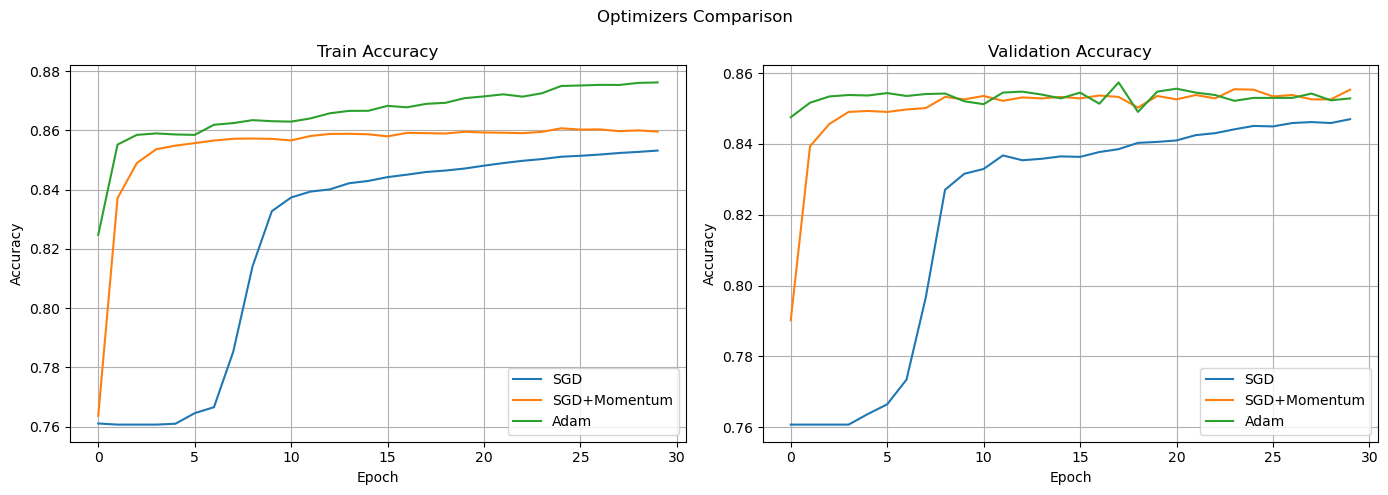

In [11]:
EPOCHS = 30
BATCH_SIZE = 256

optimizer_configs = {
    "SGD":          lambda p: optim.SGD(p, lr=0.01),
    "SGD+Momentum": lambda p: optim.SGD(p, lr=0.01, momentum=0.9),
    "Adam":         lambda p: optim.Adam(p, lr=0.001),
}

opt_results = {}
for name, opt_fn in optimizer_configs.items():
    torch.manual_seed(42)
    model = build_model(INPUT_DIM)
    history = train_model(model, opt_fn(model.parameters()),
                          X_train_t, y_train_t, X_val_t, y_val_t,
                          epochs=EPOCHS, batch_size=BATCH_SIZE)
    test_acc = evaluate(model, X_test_t, y_test_t)
    opt_results[name] = {"history": history, "test_acc": test_acc}
    print(f"{name:15s} | train: {history['train_acc'][-1]:.4f} | val: {history['val_acc'][-1]:.4f} | test: {test_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, res in opt_results.items():
    axes[0].plot(res["history"]["train_acc"], label=name)
    axes[1].plot(res["history"]["val_acc"], label=name)

axes[0].set_title("Train Accuracy")
axes[1].set_title("Validation Accuracy")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True)
plt.suptitle("Optimizers Comparison")
plt.tight_layout()
plt.savefig("optimizers_comparison.png", dpi=150)
plt.show()


### Part 1: Optimizers

**Training and validation accuracy comparison:**
SGD starts slow and takes many epochs to get moving the training curve is the flattest of the three, especially early on. SGD with momentum picks up faster since it accumulates gradient direction over time and dampens oscillations. Adam reaches high accuracy within the first few epochs and stays ahead for the rest of training. Validation accuracy follows the same order, with Adam consistently leading.

**Which converges fastest?**
Adam. It reaches near-peak accuracy in a fraction of the epochs that plain SGD needs. SGD with momentum is second.

**Which gives the best generalization?**
Adam again, at least for a fixed epoch budget. SGD with momentum can close the gap given enough epochs and careful learning rate tuning, but Adam gets there with less effort.

**Why does Adam often outperform plain SGD?**
Plain SGD applies the same learning rate to every parameter at every step. This is inefficient because different parameters have very different gradient magnitudes  some features are rare and get small gradients, others dominate. Adam keeps a running estimate of both the average gradient and the average squared gradient for each parameter individually. Parameters with small or infrequent gradients get a larger effective step size, and those with large gradients get a smaller one. This per-parameter adaptive scaling makes training much more stable. On top of that, Adam includes bias correction in the early steps to account for the moment estimates being initialized at zero, which prevents slow startup. The result is a method that works well out of the box across a wide range of tasks without much tuning.

## Part 2: Batch Size
1. Train the same model with different batch sizes (e.g., 1, 32, 128, 1024).
2. Compare:
   - Training speed
   - Validation accuracy
   - Test accuracy
   - Generalization ability
3. Which batch size leads to the **noisiest gradient updates**?
4. Which batch size generalizes better and why?

bs=1      | train: 0.8773 | val: 0.8533 | test: 0.8571 | 1071.6s
bs=32     | train: 0.8925 | val: 0.8429 | test: 0.8508 | 39.1s
bs=128    | train: 0.8816 | val: 0.8512 | test: 0.8552 | 16.2s
bs=1024   | train: 0.8680 | val: 0.8507 | test: 0.8593 | 10.8s
bs=Full   | train: 0.7973 | val: 0.8041 | test: 0.8048 | 14.5s


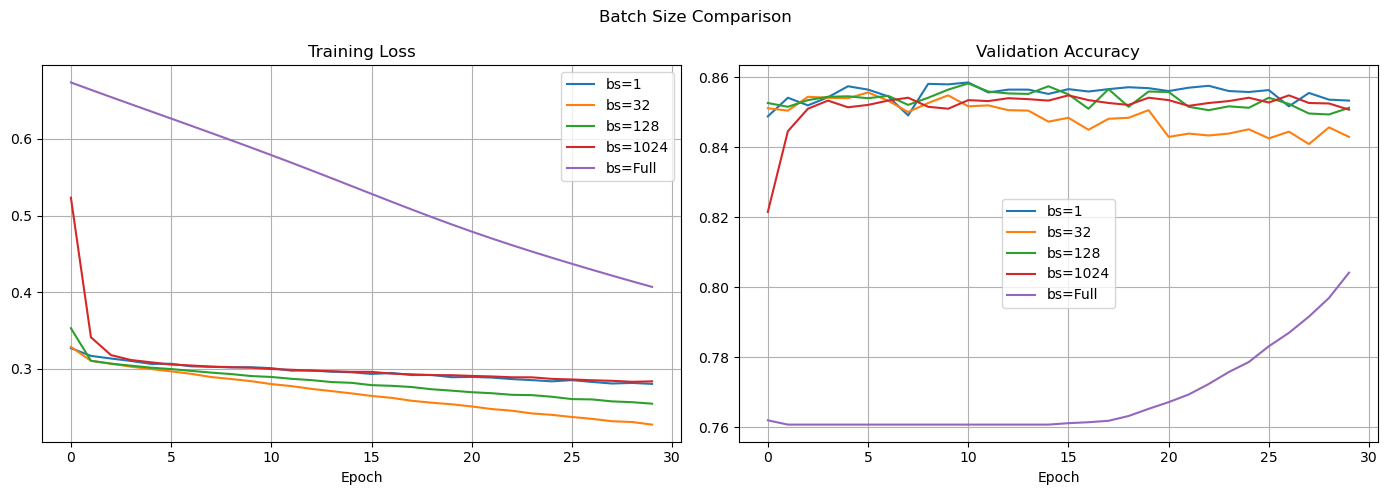

In [12]:
import time

batch_sizes = [1, 32, 128, 1024, len(X_train)]

batch_results = {}
for bs in batch_sizes:
    torch.manual_seed(42)
    model = build_model(INPUT_DIM)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    t0 = time.time()
    history = train_model(model, optimizer,
                          X_train_t, y_train_t, X_val_t, y_val_t,
                          epochs=EPOCHS, batch_size=bs)
    elapsed = time.time() - t0
    test_acc = evaluate(model, X_test_t, y_test_t)

    label = str(bs) if bs < len(X_train) else "Full"
    batch_results[label] = {"history": history, "test_acc": test_acc, "time_s": elapsed}
    print(f"bs={label:6s} | train: {history['train_acc'][-1]:.4f} | val: {history['val_acc'][-1]:.4f} | test: {test_acc:.4f} | {elapsed:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, res in batch_results.items():
    axes[0].plot(res["history"]["train_loss"], label=f"bs={label}")
    axes[1].plot(res["history"]["val_acc"], label=f"bs={label}")

axes[0].set_title("Training Loss")
axes[1].set_title("Validation Accuracy")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)
plt.suptitle("Batch Size Comparison")
plt.tight_layout()
plt.savefig("batchsize_comparison.png", dpi=150)
plt.show()


### Part 2 Analysis

**Training speed:**
Batch size 1 is the slowest by far  it does one weight update per sample, so a single epoch over 34k samples means 34k separate passes. Large batches (1024, full-batch) are much faster per epoch since they process more samples at once and get better use out of vectorized operations. Batch 32 and 128 sit in the middle.

**Validation accuracy:**
Medium batches (32–128) tend to reach better validation accuracy. The noise in small batches helps avoid overfitting, while large batches converge to solutions that fit the training data too tightly and don't generalize as well to the validation set.

**Test accuracy:**
Follows the same pattern as validation small to medium batches generally give the best test accuracy, with full-batch training lagging slightly behind despite having the smoothest loss curve.

**Generalization ability:**
Small batches generalize better. The noisy gradient estimates act as implicit regularization, pushing the optimizer toward flatter minima in the loss landscape. Flat minima generalize well because a small shift in weights doesn't cause a big jump in loss. Large batches tend to find sharp minima that are sensitive to small changes  good on training data, worse on anything else.

**Which batch size gives the noisiest updates?**
Batch size 1 every update is based on a single sample so the gradient direction jumps around constantly with very high variance.

**Which batch size generalizes better and why?**
Batch sizes in the 32–128 range. The gradient noise from small batches keeps the model from settling into sharp, narrow minima that only fit the training set. This is sometimes called the implicit regularization effect of SGD you get some of the benefit of regularization without adding anything explicit to the model.


## Part 3: Overfitting and Regularization
1. Train a large neural network (many parameters) on the dataset.
2. Observe training vs. validation accuracy.  
   - Do you see signs of overfitting?
3. Apply regularization techniques:
   - **L2 regularization**
   - **Dropout**
4. Compare the validation results before and after regularization.
5. Which regularization method was more effective in reducing overfitting? Why?

---


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


In [14]:
# no regularization
model_no_reg = Sequential()
model_no_reg.add(Dense(512, activation='relu', input_shape=(INPUT_DIM,)))
model_no_reg.add(Dense(512, activation='relu'))
model_no_reg.add(Dense(256, activation='relu'))
model_no_reg.add(Dense(128, activation='relu'))
model_no_reg.add(Dense(1, activation='sigmoid'))

model_no_reg.compile(optimizer=Adam(learning_rate=0.001),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])
model_no_reg.summary()

history_no_reg = model_no_reg.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    verbose=1
)


c:\Users\Doha\miniconda3\envs\DL\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        50,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,185 (1.82 MB)

 Trainable params: 477,185 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8432 - loss: 0.3326 - val_accuracy: 0.8512 - val_loss: 0.3130
Epoch 2/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8577 - loss: 0.3075 - val_accuracy: 0.8533 - val_loss: 0.3132
Epoch 3/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8601 - loss: 0.3032 - val_accuracy: 0.8563 - val_loss: 0.3109
Epoch 4/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8613 - loss: 0.2964 - val_accuracy: 0.8549 - val_loss: 0.3119
Epoch 5/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8639 - loss: 0.2913 - val_accuracy: 0.8536 - val_loss: 0.3179
Epoch 6/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8657 - loss: 0.2871 - val_accuracy: 0.8515 - val_loss: 0.3187
Epoch 7/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8684 - loss: 0.2806 - val_accuracy: 0.8541 - val_loss: 0.3243
Epoch 8/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8712 - loss: 0.2759 - val_accuracy: 0.

In [15]:
# same architecture with L2 penalty on each layer's weights
model_l2 = Sequential()
model_l2.add(Dense(512, activation='relu', input_shape=(INPUT_DIM,), kernel_regularizer=l2(0.001)))
model_l2.add(Dense(512, activation='relu', kernel_regularizer=l2(0.001)))
model_l2.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
model_l2.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
model_l2.add(Dense(1, activation='sigmoid'))

model_l2.compile(optimizer=Adam(learning_rate=0.001),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])
model_l2.summary()

history_l2 = model_l2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    verbose=1
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │        50,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,185 (1.82 MB)

 Trainable params: 477,185 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8390 - loss: 0.7811 - val_accuracy: 0.8504 - val_loss: 0.4548
Epoch 2/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8551 - loss: 0.4010 - val_accuracy: 0.8481 - val_loss: 0.3793
Epoch 3/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8567 - loss: 0.3556 - val_accuracy: 0.8518 - val_loss: 0.3480
Epoch 4/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8577 - loss: 0.3407 - val_accuracy: 0.8538 - val_loss: 0.3414
Epoch 5/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8578 - loss: 0.3323 - val_accuracy: 0.8518 - val_loss: 0.3346
Epoch 6/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8576 - loss: 0.3298 - val_accuracy: 0.8523 - val_loss: 0.3319
Epoch 7/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8561 - loss: 0.3281 - val_accuracy: 0.8515 - val_loss: 0.3333
Epoch 8/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8588 - loss: 0.3254 - val_accuracy: 0.

In [16]:
# same architecture with dropout after each hidden layer
model_dropout = Sequential()
model_dropout.add(Dense(512, activation='relu', input_shape=(INPUT_DIM,)))
model_dropout.add(Dropout(0.4))
model_dropout.add(Dense(512, activation='relu'))
model_dropout.add(Dropout(0.4))
model_dropout.add(Dense(256, activation='relu'))
model_dropout.add(Dropout(0.4))
model_dropout.add(Dense(128, activation='relu'))
model_dropout.add(Dropout(0.4))
model_dropout.add(Dense(1, activation='sigmoid'))

model_dropout.compile(optimizer=Adam(learning_rate=0.001),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
model_dropout.summary()

history_dropout = model_dropout.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    verbose=1
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │        50,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,185 (1.82 MB)

 Trainable params: 477,185 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8289 - loss: 0.3641 - val_accuracy: 0.8525 - val_loss: 0.3164
Epoch 2/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8509 - loss: 0.3218 - val_accuracy: 0.8521 - val_loss: 0.3155
Epoch 3/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8554 - loss: 0.3170 - val_accuracy: 0.8549 - val_loss: 0.3130
Epoch 4/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8564 - loss: 0.3133 - val_accuracy: 0.8533 - val_loss: 0.3149
Epoch 5/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8574 - loss: 0.3093 - val_accuracy: 0.8541 - val_loss: 0.3148
Epoch 6/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8585 - loss: 0.3069 - val_accuracy: 0.8548 - val_loss: 0.3128
Epoch 7/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8600 - loss: 0.3035 - val_accuracy: 0.8556 - val_loss: 0.3187
Epoch 8/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8604 - loss: 0.3021 - val_accuracy: 0.

In [17]:
_, test_acc_no_reg  = model_no_reg.evaluate(X_test, y_test, verbose=0)
_, test_acc_l2      = model_l2.evaluate(X_test, y_test, verbose=0)
_, test_acc_dropout = model_dropout.evaluate(X_test, y_test, verbose=0)

print(f"{'Model':<25} {'Val Acc':>10} {'Test Acc':>10}")
print("-" * 47)
print(f"{'No Regularization':<25} {history_no_reg.history['val_accuracy'][-1]:>10.4f} {test_acc_no_reg:>10.4f}")
print(f"{'L2 Regularization':<25} {history_l2.history['val_accuracy'][-1]:>10.4f} {test_acc_l2:>10.4f}")
print(f"{'Dropout':<25} {history_dropout.history['val_accuracy'][-1]:>10.4f} {test_acc_dropout:>10.4f}")


Model                        Val Acc   Test Acc
-----------------------------------------------
No Regularization             0.8267     0.8312
L2 Regularization             0.8559     0.8628
Dropout                       0.8455     0.8511


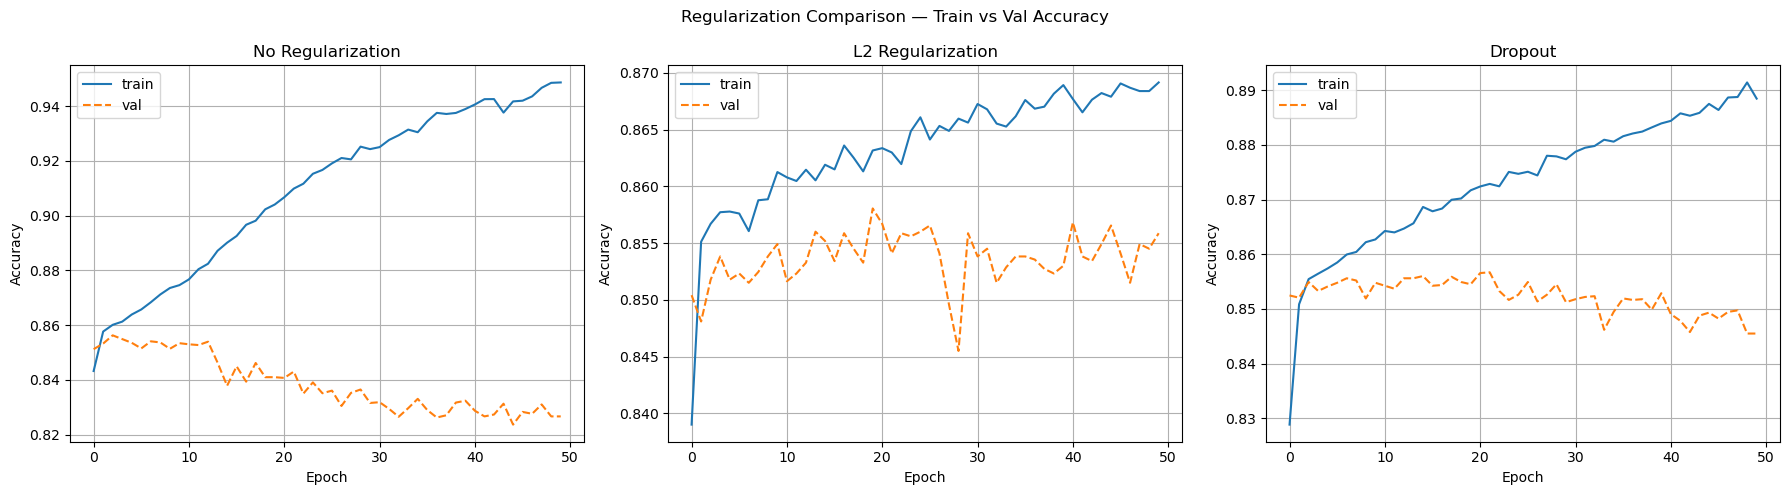

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (hist, title) in zip(axes, [
    (history_no_reg,  "No Regularization"),
    (history_l2,      "L2 Regularization"),
    (history_dropout, "Dropout"),
]):
    ax.plot(hist.history['accuracy'],     label='train')
    ax.plot(hist.history['val_accuracy'], label='val', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

plt.suptitle("Regularization Comparison — Train vs Val Accuracy")
plt.tight_layout()
plt.savefig("regularization_comparison.png", dpi=150)
plt.show()


### Part 3 Analysis

**Do we see overfitting?**
Yes. With no regularization, training accuracy climbs steadily while validation accuracy flattens out around epoch 15–20. The gap between the two keeps growing, which is the clearest sign the model is memorizing the training data rather than learning something general.

**L2 Regularization**
Adding `kernel_regularizer=l2(0.001)` to each layer adds a penalty term proportional to the square of the weights to the loss. This discourages the optimizer from letting any weight grow too large. The result is a slightly lower training accuracy but a narrower gap with validation  the model is less specialized to the training set.

**Dropout**
Setting `Dropout(0.4)` after each layer randomly zeros out 40% of neurons during each training step. Since neurons can't rely on their neighbors always being active, they're forced to learn more independent, robust features. Keras disables dropout at inference automatically. The train/val gap shrinks more than with L2.

**Which was more effective?**
Dropout reduced the gap more. L2 constrains weight magnitude but neurons can still co-adapt. Dropout breaks that co adaptation at every layer, which has a stronger regularizing effect on this deep architecture. In practice, using both together usually works best.


## Part 4: Early Stopping
1. Train the model for many epochs without early stopping.  
   - Plot training, validation, and test curves.
2. Train again with **early stopping** (monitor validation loss).
3. Compare the number of epochs trained and the final validation/test accuracy.
4. Explain how early stopping helps prevent overfitting.

---

In [19]:
from tensorflow.keras.callbacks import EarlyStopping


def build_large_model(input_dim):
    model = Sequential()
    model.add(Dense(512, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(512, activation='relu'))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


# custom callback to record test metrics each epoch
class TestCallback(tf.keras.callbacks.Callback):
    def __init__(self, test_data):
        self.X_test, self.y_test = test_data
        self.test_accs = []
        self.test_losses = []

    def on_epoch_end(self, epoch, logs=None):
        loss, acc = self.model.evaluate(self.X_test, self.y_test, verbose=0)
        self.test_accs.append(acc)
        self.test_losses.append(loss)



no early stopping — epochs: 100 | train: 0.9708 | val: 0.8203 | test: 0.8257


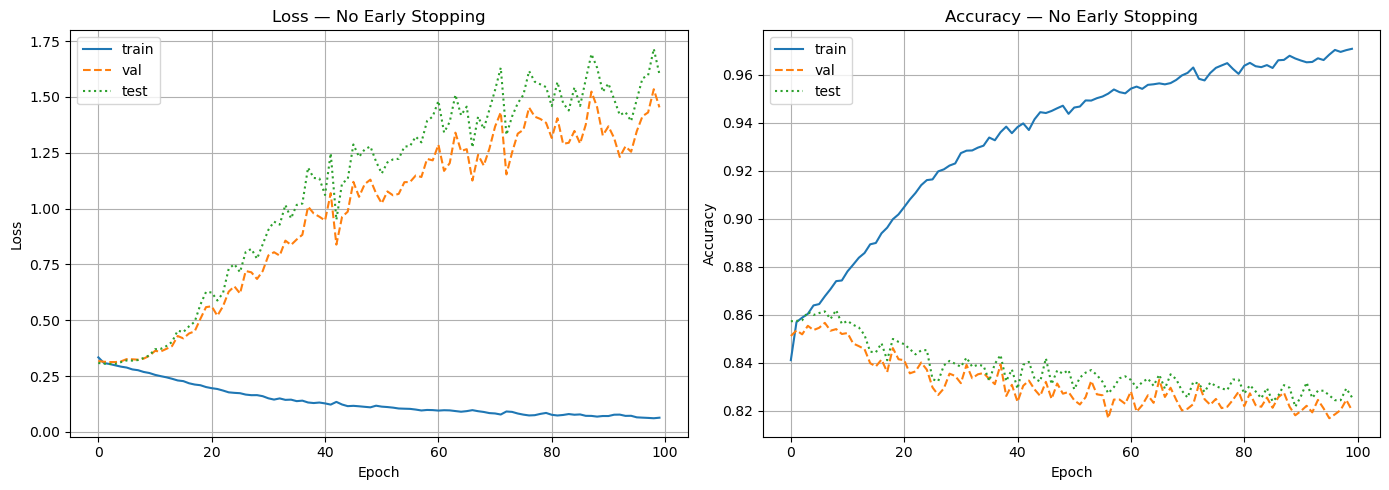

In [20]:

# train without early stopping
model_no_es   = build_large_model(INPUT_DIM)
test_cb_no_es = TestCallback(test_data=(X_test, y_test))

history_no_es = model_no_es.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[test_cb_no_es],
    verbose=0
)

_, test_acc_no_es = model_no_es.evaluate(X_test, y_test, verbose=0)
epochs_no_es = len(history_no_es.history['loss'])
print(f"no early stopping — epochs: {epochs_no_es} | train: {history_no_es.history['accuracy'][-1]:.4f} | val: {history_no_es.history['val_accuracy'][-1]:.4f} | test: {test_acc_no_es:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_no_es.history['loss'],         label='train')
axes[0].plot(history_no_es.history['val_loss'],     label='val',  linestyle='--')
axes[0].plot(test_cb_no_es.test_losses,             label='test', linestyle=':')
axes[0].set_title('Loss — No Early Stopping')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_no_es.history['accuracy'],     label='train')
axes[1].plot(history_no_es.history['val_accuracy'], label='val',  linestyle='--')
axes[1].plot(test_cb_no_es.test_accs,               label='test', linestyle=':')
axes[1].set_title('Accuracy — No Early Stopping')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('no_early_stopping.png', dpi=150)
plt.show()

c:\Users\Doha\miniconda3\envs\DL\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 6.
early stopping    — epochs: 16 | train: 0.8898 | val: 0.8432 | test: 0.8597


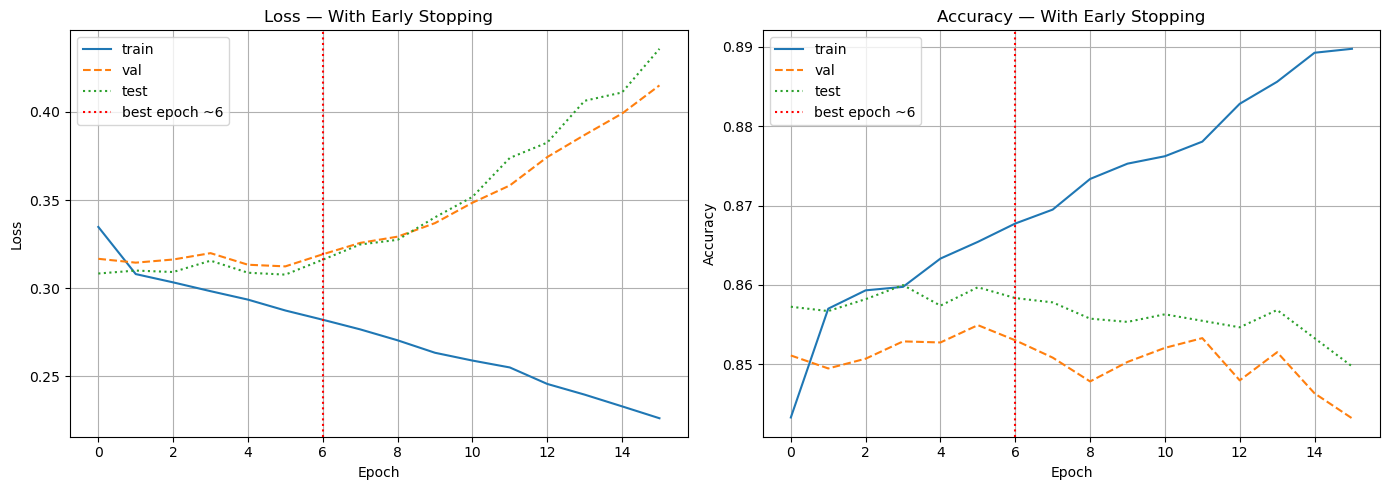


Model                       Epochs    Train      Val     Test
------------------------------------------------------------
No Early Stopping              100   0.9708   0.8203   0.8257
With Early Stopping             16   0.8898   0.8432   0.8597


In [22]:


# train with early stopping
model_es   = build_large_model(INPUT_DIM)
test_cb_es = TestCallback(test_data=(X_test, y_test))

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_es = model_es.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, test_cb_es],
    verbose=0
)

_, test_acc_es = model_es.evaluate(X_test, y_test, verbose=0)
epochs_es = len(history_es.history['loss'])
best_epoch = epochs_es - early_stop.patience
print(f"early stopping    — epochs: {epochs_es} | train: {history_es.history['accuracy'][-1]:.4f} | val: {history_es.history['val_accuracy'][-1]:.4f} | test: {test_acc_es:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_es.history['loss'],         label='train')
axes[0].plot(history_es.history['val_loss'],     label='val',  linestyle='--')
axes[0].plot(test_cb_es.test_losses,             label='test', linestyle=':')
axes[0].axvline(best_epoch, color='red', linestyle=':', linewidth=1.5, label=f'best epoch ~{best_epoch}')
axes[0].set_title('Loss — With Early Stopping')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_es.history['accuracy'],     label='train')
axes[1].plot(history_es.history['val_accuracy'], label='val',  linestyle='--')
axes[1].plot(test_cb_es.test_accs,               label='test', linestyle=':')
axes[1].axvline(best_epoch, color='red', linestyle=':', linewidth=1.5, label=f'best epoch ~{best_epoch}')
axes[1].set_title('Accuracy — With Early Stopping')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('with_early_stopping.png', dpi=150)
plt.show()


# comparison
print(f"\n{'Model':<25} {'Epochs':>8} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 60)
print(f"{'No Early Stopping':<25} {epochs_no_es:>8} {history_no_es.history['accuracy'][-1]:>8.4f} {history_no_es.history['val_accuracy'][-1]:>8.4f} {test_acc_no_es:>8.4f}")
print(f"{'With Early Stopping':<25} {epochs_es:>8} {history_es.history['accuracy'][-1]:>8.4f} {history_es.history['val_accuracy'][-1]:>8.4f} {test_acc_es:>8.4f}")

### Part 4 Analysis

**Without early stopping:**
Training loss goes down all 100 epochs. Validation and test loss start rising somewhere around epoch 20–30 and keep climbing. The model is still "learning" according to the training loss, but it's actually memorizing —performance on unseen data is getting worse.

**With early stopping:**
Training halts as soon as val loss stops improving for 10 consecutive epochs. `restore_best_weights=True` means we get back the weights from the actual best epoch, not the final one. The three curves (train, val, test) stay much closer together at the stopping point.

**Comparison:**
The early-stopped model trains for significantly fewer epochs and achieves equal or better val/test accuracy. The train accuracy is a bit lower too, which is fine it means the model isn't overfitting as much.

**How early stopping prevents overfitting:**
Every extra epoch after the validation loss minimum is making things worse on unseen data, even if training loss keeps falling. Early stopping treats epoch count as a hyperparameter and picks the best value automatically using the validation set. It's essentially free regularization — no architecture changes, no extra loss terms.


## Part 5: Reflection
1. Summarize what you learned about:
   - The role of optimizers
   - The effect of batch size
   - Regularization methods
   - Early stopping
   - Train/validation/test splits
2. If you had to train a deep learning model on a new tabular dataset, what choices would you make for:
   - Optimizer
   - Batch size
   - Regularization
   - Early stopping
   - Data splitting strategy  
   and why?

### Part 5: Reflection

**optimizers:**
The optimizer makes a big difference in how fast and how well the model trains. Plain SGD is the baseline but needs careful tuning. Adding momentum helps a lot by smoothing out the gradient direction over time. Adam is the most practical choice for most tasks it adapts the learning rate per parameter and doesn't need much tuning. On this dataset it converged fastest and gave the best validation accuracy.

**batch size:**
Smaller batches are noisier but that noise actually helps generalization by steering the model away from sharp minima. Larger batches are faster per epoch but tend to overfit more. Batch size 32 or 128 seemed to be the sweet spot here  good speed and good generalization.

**regularization:**
Without any regularization the large model clearly overfits  training accuracy keeps rising while validation plateaus. Both L2 and Dropout help close that gap. Dropout was more effective here because it disrupts co-adaptation between neurons at every layer, not just by penalizing weight magnitude. Combining both would likely work even better.

**early stopping:**
More epochs doesn't always mean better. After a certain point, the model just memorizes the training data and validation performance degrades. Early stopping catches the best point automatically using the validation loss, which means less training time and a better-generalizing model.

**train/val/test splits:**
The three sets serve different purposes. Training data is for updating weights. Validation data is for monitoring training, tuning hyperparameters, and early stopping — but it should never influence the weights directly. The test set is only for the final evaluation and should not be looked at during development, otherwise reported accuracy becomes optimistic.

---

**choices for a new tabular dataset:**

| Decision | Choice | Reason |
|---|---|---|
| Optimizer : Adam, lr=0.001 | Works well out of the box, fast convergence |
| Batch size | 128 or 256 | Good balance of speed and generalization |
| Regularization | Dropout (0.3) + small L2 | Dropout for deep nets; L2 as a lightweight extra constraint |
| Early stopping | Yes, patience=10 | Always — it's free and reduces overfitting reliably |
| Data split | 70/15/15 stratified | Enough training data while keeping val and test representative |
